# Athlete-centric models: environment and relative performance

**Relative performance** is predicted using **World Aquatics / FINA points** so the model generalizes across events. **Swimmers across meets** are linked via `person_id` with leakage-safe baselines.

**Targets:** (A) within-(meet,event) z-score of points; (B) athlete delta-points vs their own baseline for that event (computed from training data only).

**Evaluation:** Meet-holdout split. Baselines: event-only mean; then linear + tree models with env + event (and optionally athlete) effects.

In [46]:
# Optional: use race-time weather if available (run: python3 -m src.weather.race_time_weather)
RACE_TIME_CSV = PROCESSED / "results_with_race_time_weather.csv"
ENV_CSV = PROCESSED / "results_with_environment.csv"
use_race_time = False
if RACE_TIME_CSV.exists():
    df_rt = pd.read_csv(RACE_TIME_CSV)
    if "points" in df_rt.columns:
        rt_map = {"race_time_temperature": "temperature", "race_time_dewpoint": "dewpoint", "race_time_wind_speed": "wind_speed",
                  "race_time_pressure": "pressure", "race_time_relative_humidity": "relative_humidity", "race_time_wbgt": "wbgt"}
        for rt_col, std_name in rt_map.items():
            if rt_col in df_rt.columns:
                df_rt[std_name] = df_rt[rt_col]
        df = df_rt[(df_rt["phase"] == "Finals") & (df_rt["points"].notna())].copy()
        use_race_time = True
        print("Using race-time weather from", RACE_TIME_CSV.name)
    else:
        print("Race-time CSV lacks 'points' (stale). Re-run: 01_join then python3 -m src.weather.race_time_weather")
if not use_race_time:
    df = pd.read_csv(ENV_CSV)
    df = df[(df["phase"] == "Finals") & (df["points"].notna())].copy()
    print("Using meet-level weather from", ENV_CSV.name)
df["event_key"] = df["discipline_name"].astype(str) + "_" + df["gender"].astype(str)

Using race-time weather from results_with_race_time_weather.csv


In [47]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "notebooks").exists() else Path.cwd().parent
PROCESSED = PROJECT_ROOT / "data" / "processed"
DF_PATH = PROCESSED / "results_with_environment.csv"

df = pd.read_csv(DF_PATH)
df = df[(df["phase"] == "Finals") & (df["points"].notna())].copy()
assert "person_id" in df.columns, "Run 01_join_results_environment first; ensure person_id is in the SQL."
df["event_key"] = df["discipline_name"].astype(str) + "_" + df["gender"].astype(str)
print("Rows:", len(df), "Columns:", list(df.columns))

Rows: 4846 Columns: ['meet_id', 'person_id', 'race_start_time', 'discipline_name', 'gender', 'phase', 'points', 'time_str', 'rank', 'athlete_name', 'country_code', 'time_seconds', 'meet_name', 'start_date', 'end_date', 'use_era5_land', 'lat', 'lon', 'elevation', 'timezone', 'temperature', 'dewpoint', 'wind_speed', 'pressure', 'relative_humidity', 'wbgt', 'city', 'country', 'event_key']


## Step 0 — Data readiness

Check: swimmers in multiple meets; coverage per meet; valid times; env missingness.

In [48]:
meets_per_athlete = df.groupby("person_id")["meet_id"].nunique()
print("Meets per athlete:", meets_per_athlete.describe())
print("Athletes in 2+ meets:", (meets_per_athlete >= 2).sum())
print("Athletes in 3+ meets:", (meets_per_athlete >= 3).sum())
results_per_meet = df.groupby("meet_id").size()
print("\nResults per meet:", results_per_meet.describe())
env_cols = ["temperature", "pressure", "wbgt", "elevation", "relative_humidity", "wind_speed"]
missing = df[env_cols].isna().any(axis=1).sum()
print("\nRows with any env missing:", missing)

Meets per athlete: count    1404.000000
mean        1.942308
std         1.441748
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        11.000000
Name: meet_id, dtype: float64
Athletes in 2+ meets: 651
Athletes in 3+ meets: 308

Results per meet: count     16.000000
mean     302.875000
std      109.534089
min       80.000000
25%      254.750000
50%      317.000000
75%      335.250000
max      558.000000
dtype: float64

Rows with any env missing: 0


## Step 1 — Relative targets

**Target A:** z-score within (meet_id, event_key).  
**Target B:** delta vs athlete's own median points for that event — this is computed **after** splitting (train baseline only) to avoid leakage.

In [49]:
# Target A: within-(meet, event) z-score (no leakage)
meet_event = df.groupby(["meet_id", "event_key"])["points"]
mu = meet_event.transform("mean")
sig = meet_event.transform("std")
df["z_score"] = (df["points"] - mu) / sig.replace(0, np.nan)
df = df.dropna(subset=["z_score"]).copy()
print("Target A (z_score) — rows retained:", len(df))
print("z_score summary:", df["z_score"].describe())

Target A (z_score) — rows retained: 4846
z_score summary: count    4.846000e+03
mean    -1.686183e-17
std      9.442674e-01
min     -2.393875e+00
25%     -7.347252e-01
50%     -6.425040e-02
75%      7.172350e-01
max      2.993650e+00
Name: z_score, dtype: float64


## Step 2 — Meet-holdout split and leakage-safe Target B

Split by meet_id. For Target B, compute each athlete-event baseline using **only training meets**.

In [50]:
from sklearn.model_selection import train_test_split

meet_ids = df["meet_id"].unique()
train_meets, test_meets = train_test_split(meet_ids, test_size=0.25, random_state=42)
df["is_train"] = df["meet_id"].isin(train_meets)

# Baseline (median points) per (person_id, event_key) using TRAIN only
train_df = df[df["is_train"]].copy()
baseline = train_df.groupby(["person_id", "event_key"])["points"].median().reset_index()
baseline.columns = ["person_id", "event_key", "baseline_points"]
df = df.merge(baseline, on=["person_id", "event_key"], how="left")
# For test rows, baseline can be NaN (swimmer-event not in train); drop those for Target B
df["delta_points"] = df["points"] - df["baseline_points"]
df["pct_delta"] = (df["points"] - df["baseline_points"]) / df["baseline_points"].replace(0, np.nan)
print("Train meets:", len(train_meets), "Test meets:", len(test_meets))
print("Target B (delta_points) — rows with valid baseline:", df["delta_points"].notna().sum())

Train meets: 12 Test meets: 4
Target B (delta_points) — rows with valid baseline: 3892


In [51]:
train_df = df[df["is_train"]].copy()
test_df = df[df["meet_id"].isin(test_meets)].copy()
# For Target B: restrict rows that have a baseline (swimmer-event seen in train)
test_b = test_df[test_df["delta_points"].notna()].copy()
train_b = train_df[train_df["delta_points"].notna()].copy()
print("Train size (A):", len(train_df), "Test size (A):", len(test_df))
print("Train size (B):", len(train_b), "Test size (B):", len(test_b))

Train size (A): 3889 Test size (A): 957
Train size (B): 3346 Test size (B): 546


## Step 3 — Feature matrices and baselines

Env features + event_key (one-hot or label). event_key encoding avoids exposing raw time scale to the model.

In [52]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ENV_FEATURES = ["temperature", "pressure", "wbgt", "elevation", "relative_humidity", "wind_speed"]
for c in ENV_FEATURES:
    train_df[c] = train_df[c].fillna(train_df[c].median())
    test_df[c] = test_df[c].fillna(test_df[c].median())
    train_b[c] = train_b[c].fillna(train_b[c].median())
    test_b[c] = test_b[c].fillna(test_b[c].median())

le = LabelEncoder()
le.fit(df["event_key"])
train_df["event_enc"] = le.transform(train_df["event_key"])
test_df["event_enc"] = le.transform(test_df["event_key"])
train_b["event_enc"] = le.transform(train_b["event_key"])
test_b["event_enc"] = le.transform(test_b["event_key"])

feature_cols = ["event_enc"] + ENV_FEATURES
X_train_a = train_df[feature_cols]
X_test_a = test_df[feature_cols]
X_train_b = train_b[feature_cols]
X_test_b = test_b[feature_cols]
y_train_a = train_df["z_score"].values
y_test_a = test_df["z_score"].values
y_train_b = train_b["delta_points"].values
y_test_b = test_b["delta_points"].values

In [53]:
# Baseline A: predict 0 (mean z per meet-event is 0 by construction; global mean z ≈ 0)
baseline_pred_a = np.zeros_like(y_test_a)
print("Baseline A (predict 0 for z_score): MAE = {:.4f}, R² = {:.4f}".format(
    mean_absolute_error(y_test_a, baseline_pred_a), r2_score(y_test_a, baseline_pred_a)))

# Baseline B: predict 0 (mean delta_points in train is ~0 per athlete-event)
baseline_pred_b = np.zeros_like(y_test_b)
print("Baseline B (predict 0 for delta_points): MAE = {:.4f}, R² = {:.4f}".format(
    mean_absolute_error(y_test_b, baseline_pred_b), r2_score(y_test_b, baseline_pred_b)))

Baseline A (predict 0 for z_score): MAE = 0.7847, R² = 0.0000
Baseline B (predict 0 for delta_points): MAE = 32.2363, R² = -0.0004


## Step 4 — Models: Ridge and Random Forest

Train on both targets. Scale features for Ridge.

In [54]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

scaler = StandardScaler()
X_tr_a_s = scaler.fit_transform(X_train_a)
X_te_a_s = scaler.transform(X_test_a)
X_tr_b_s = scaler.fit_transform(X_train_b)
X_te_b_s = scaler.transform(X_test_b)

ridge_a = Ridge(alpha=1.0, random_state=42).fit(X_tr_a_s, y_train_a)
ridge_b = Ridge(alpha=1.0, random_state=42).fit(X_tr_b_s, y_train_b)
pred_ridge_a = ridge_a.predict(X_te_a_s)
pred_ridge_b = ridge_b.predict(X_te_b_s)

print("Ridge — Target A (z_score):  MAE = {:.4f}, R² = {:.4f}".format(
    mean_absolute_error(y_test_a, pred_ridge_a), r2_score(y_test_a, pred_ridge_a)))
print("Ridge — Target B (delta_points): MAE = {:.4f}, R² = {:.4f}".format(
    mean_absolute_error(y_test_b, pred_ridge_b), r2_score(y_test_b, pred_ridge_b)))

rf_a = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_b = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_a.fit(X_train_a, y_train_a)
rf_b.fit(X_train_b, y_train_b)
pred_rf_a = rf_a.predict(X_test_a)
pred_rf_b = rf_b.predict(X_test_b)
print("RF — Target A (z_score):  MAE = {:.4f}, R² = {:.4f}".format(
    mean_absolute_error(y_test_a, pred_rf_a), r2_score(y_test_a, pred_rf_a)))
print("RF — Target B (delta_points): MAE = {:.4f}, R² = {:.4f}".format(
    mean_absolute_error(y_test_b, pred_rf_b), r2_score(y_test_b, pred_rf_b)))

Ridge — Target A (z_score):  MAE = 0.7847, R² = 0.0000
Ridge — Target B (delta_points): MAE = 34.2891, R² = -0.0598
RF — Target A (z_score):  MAE = 0.7846, R² = -0.0009
RF — Target B (delta_points): MAE = 31.3762, R² = 0.0770


## Step 5 — Coefficients (Ridge) and feature importance (RF)

Interpret env effects from Ridge; compare to RF importance.

In [55]:
coef_df = pd.DataFrame({"feature": feature_cols, "coef_z": ridge_a.coef_, "coef_delta": ridge_b.coef_})
print("Ridge coefficients (Target A = z_score, Target B = delta_points):")
print(coef_df.to_string(index=False))

imp_a = pd.Series(rf_a.feature_importances_, index=feature_cols).sort_values(ascending=False)
imp_b = pd.Series(rf_b.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nRF feature importance (Target A):", imp_a.to_string())
print("\nRF feature importance (Target B):", imp_b.to_string())

Ridge coefficients (Target A = z_score, Target B = delta_points):
          feature        coef_z  coef_delta
        event_enc  3.943704e-17   -0.049824
      temperature -1.673048e-14   37.443288
         pressure -7.791413e-17   -2.837015
             wbgt  1.883933e-14  -42.399267
        elevation -6.321179e-17   -3.018279
relative_humidity -4.648891e-15    3.227758
       wind_speed -1.440197e-16   -5.240169

RF feature importance (Target A): event_enc            0.614905
relative_humidity    0.079316
pressure             0.079183
wind_speed           0.072554
elevation            0.056122
wbgt                 0.052516
temperature          0.045403

RF feature importance (Target B): event_enc            0.369366
wind_speed           0.299699
temperature          0.101742
wbgt                 0.077734
relative_humidity    0.063042
pressure             0.059274
elevation            0.029143


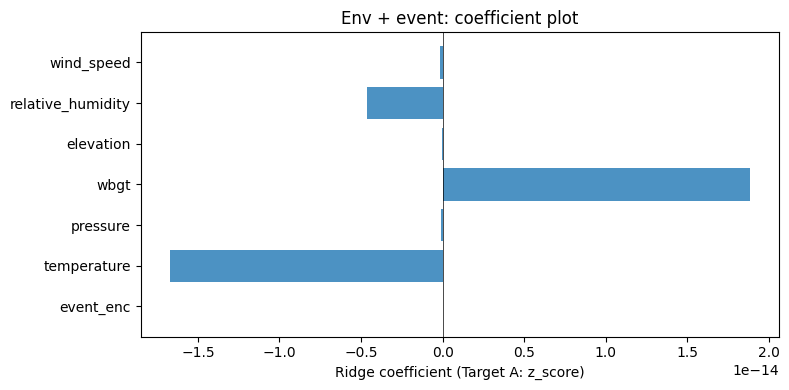

In [56]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(feature_cols))
ax.barh(feature_cols, ridge_a.coef_, alpha=0.8, label="z_score")
ax.axvline(0, color="k", linewidth=0.5)
ax.set_xlabel("Ridge coefficient (Target A: z_score)")
ax.set_title("Env + event: coefficient plot")
plt.tight_layout()
plt.show()

## Step 6 — Visualizations

Predicted vs actual (Target A); residuals; within-event scatter (one event: env vs mean delta_points per meet).

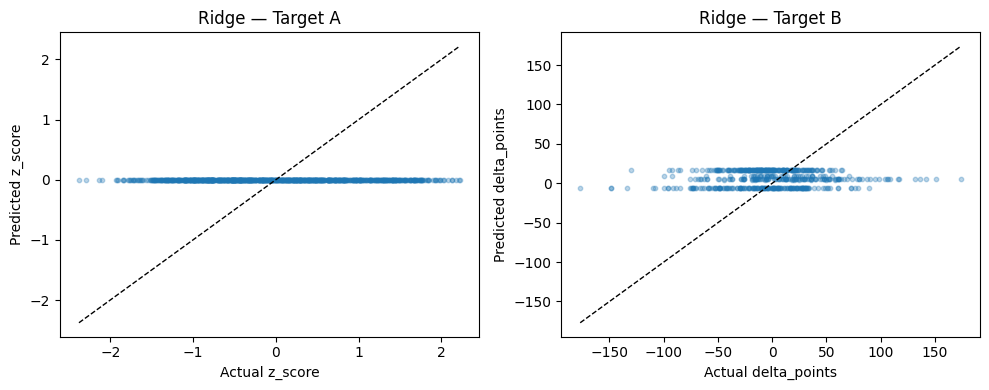

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(y_test_a, pred_ridge_a, alpha=0.3, s=10)
axes[0].plot([y_test_a.min(), y_test_a.max()], [y_test_a.min(), y_test_a.max()], "k--", lw=1)
axes[0].set_xlabel("Actual z_score")
axes[0].set_ylabel("Predicted z_score")
axes[0].set_title("Ridge — Target A")
axes[1].scatter(y_test_b, pred_ridge_b, alpha=0.3, s=10)
axes[1].plot([y_test_b.min(), y_test_b.max()], [y_test_b.min(), y_test_b.max()], "k--", lw=1)
axes[1].set_xlabel("Actual delta_points")
axes[1].set_ylabel("Predicted delta_points")
axes[1].set_title("Ridge — Target B")
plt.tight_layout()
plt.show()

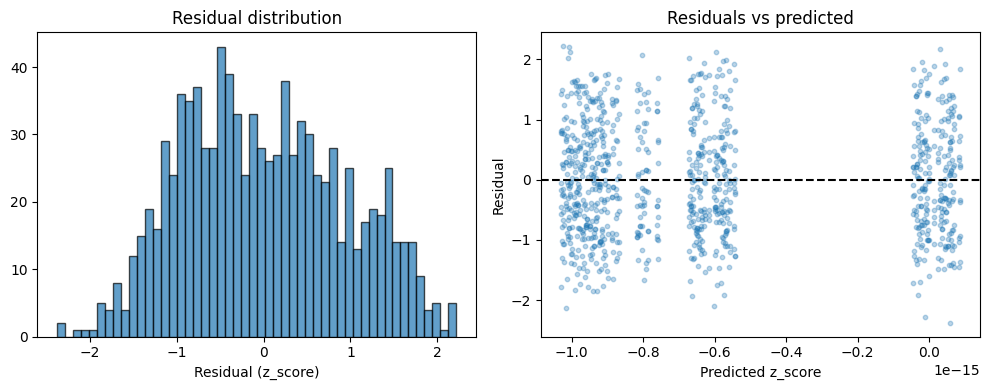

In [58]:
resid_a = y_test_a - pred_ridge_a
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(resid_a, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Residual (z_score)")
axes[0].set_title("Residual distribution")
axes[1].scatter(pred_ridge_a, resid_a, alpha=0.3, s=10)
axes[1].axhline(0, color="k", linestyle="--")
axes[1].set_xlabel("Predicted z_score")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs predicted")
plt.tight_layout()
plt.show()

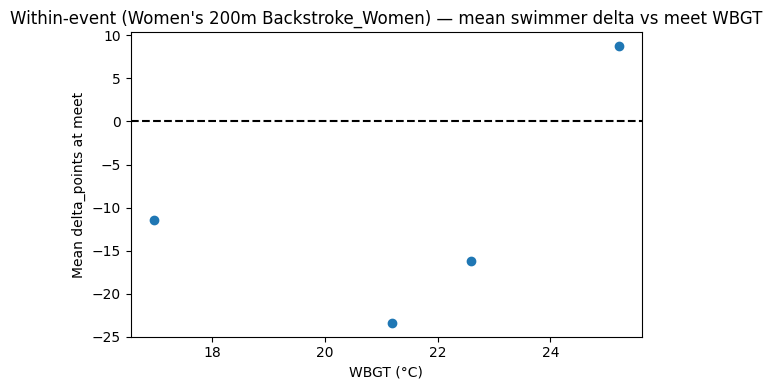

In [59]:
# Within-event: one event, mean delta_points per meet vs WBGT (or pressure)
ev = test_b["event_key"].value_counts().index[0]
sub = test_b[test_b["event_key"] == ev].copy()
meet_agg = sub.groupby("meet_id").agg({"delta_points": "mean", "wbgt": "first", "temperature": "first", "pressure": "first"}).reset_index()
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(meet_agg["wbgt"], meet_agg["delta_points"])
ax.axhline(0, color="k", linestyle="--")
ax.set_xlabel("WBGT (°C)")
ax.set_ylabel("Mean delta_points at meet")
ax.set_title("Within-event ({}) — mean swimmer delta vs meet WBGT".format(ev))
plt.tight_layout()
plt.show()

## How to improve

**Why results are weak:** (1) **Meet-average weather** is a poor proxy for conditions at race time (indoor pools, AC, race hour). (2) Only **~22 meets** so env variation is limited. (3) **Noise**: many heats per meet, strategy (heats vs finals), one-off athletes.

**Quick wins (below):**
- **Repeat swimmers only** (3+ meets): more stable baselines, less noise.
- **One row per athlete–meet–event**: take **best time** (or finals only) so each swimmer contributes one observation per meet per event.
- **Finals only**: reduces strategy noise.
- **Meet–event aggregation**: one row per (meet, event) = mean delta_points or mean z; regress env on that. Fewer points but less within-meet noise; sometimes reveals env signal.

**Bigger levers (next steps):**
- **Race-time weather**: add `race_start_time` to the join, align ERA5 **hourly** to that time (and timezone). Then use conditions at race hour instead of meet average.
- **More meets / longer history**: more env and athlete variation.
- **Mixed-effects model**: random effects for athlete and event; estimate env as fixed effect (e.g. `statsmodels` or `pymer4`).

In [60]:
# --- 1) Repeat swimmers only (3+ meets): more stable baselines ---
meets_per_athlete = df.groupby("person_id")["meet_id"].nunique()
repeat_ids = meets_per_athlete[meets_per_athlete >= 3].index
train_br = train_b[train_b["person_id"].isin(repeat_ids)].copy()
test_br = test_b[test_b["person_id"].isin(repeat_ids)].copy()
for c in ENV_FEATURES:
    train_br[c] = train_br[c].fillna(train_br[c].median())
    test_br[c] = test_br[c].fillna(test_br[c].median())
Xtr_br = train_br[feature_cols]
Xte_br = test_br[feature_cols]
scaler_br = StandardScaler()
ridge_br = Ridge(alpha=1.0, random_state=42).fit(scaler_br.fit_transform(Xtr_br), train_br["delta_points"].values)
r2_repeat = r2_score(test_br["delta_points"].values, ridge_br.predict(scaler_br.transform(Xte_br)))
print("1) Repeat swimmers only (3+ meets), Target B — R² = {:.4f}  (n_train={}, n_test={})".format(
    r2_repeat, len(train_br), len(test_br)))

# --- 2) Meet–event aggregation: one row per (meet, event), mean delta_points and mean z ---
agg_meet_event = df.groupby(["meet_id", "event_key"]).agg(
    mean_z=("z_score", "mean"),
    mean_delta_points=("delta_points", "mean"),
    temperature=("temperature", "first"),
    pressure=("pressure", "first"),
    wbgt=("wbgt", "first"),
    elevation=("elevation", "first"),
    relative_humidity=("relative_humidity", "first"),
    wind_speed=("wind_speed", "first"),
).reset_index()
agg_meet_event = agg_meet_event.dropna(subset=["mean_delta_points"])
agg_meet_event["event_enc"] = le.transform(agg_meet_event["event_key"])
agg_train = agg_meet_event[agg_meet_event["meet_id"].isin(train_meets)]
agg_test = agg_meet_event[agg_meet_event["meet_id"].isin(test_meets)]
for c in ENV_FEATURES:
    agg_train[c] = agg_train[c].fillna(agg_train[c].median())
    agg_test[c] = agg_test[c].fillna(agg_test[c].median())
X_agg_tr = agg_train[feature_cols]
X_agg_te = agg_test[feature_cols]
scaler_agg = StandardScaler()
ridge_agg = Ridge(alpha=1.0, random_state=42).fit(
    scaler_agg.fit_transform(X_agg_tr), agg_train["mean_delta_points"].values)
r2_agg = r2_score(agg_test["mean_delta_points"].values, ridge_agg.predict(scaler_agg.transform(X_agg_te)))
print("2) Meet–event aggregation (mean delta_points), Ridge — R² = {:.4f}  (n_train={}, n_test={})".format(
    r2_agg, len(agg_train), len(agg_test)))

# --- 3) Finals only (if phase column exists): less strategy noise ---
if "phase" in df.columns:
    fin = df[df["phase"] == "Finals"].copy()
    if len(fin) > 1000:
        fin["is_train"] = fin["meet_id"].isin(train_meets)
        # fin already has baseline_points and delta_points from df (Step 2 merge); no need to merge baseline again
        train_f = fin[fin["is_train"]].copy()
        test_f = fin[~fin["is_train"]].copy()
        train_f = train_f[train_f["delta_points"].notna()]
        test_f = test_f[test_f["delta_points"].notna()]
        for c in ENV_FEATURES:
            train_f[c] = train_f[c].fillna(train_f[c].median())
            test_f[c] = test_f[c].fillna(test_f[c].median())
        train_f["event_enc"] = le.transform(train_f["event_key"])
        test_f["event_enc"] = le.transform(test_f["event_key"])
        Xf_tr = train_f[feature_cols]
        Xf_te = test_f[feature_cols]
        scaler_f = StandardScaler()
        ridge_f = Ridge(alpha=1.0, random_state=42).fit(scaler_f.fit_transform(Xf_tr), train_f["delta_points"].values)
        r2_fin = r2_score(test_f["delta_points"].values, ridge_f.predict(scaler_f.transform(Xf_te)))
        print("3) Finals only, Target B — R² = {:.4f}  (n_train={}, n_test={})".format(r2_fin, len(train_f), len(test_f)))
    else:
        print("3) Finals only — skipped (too few rows)")
else:
    print("3) Finals only — skipped (no 'phase' in data)")

1) Repeat swimmers only (3+ meets), Target B — R² = -0.0402  (n_train=1714, n_test=409)
2) Meet–event aggregation (mean delta_points), Ridge — R² = -0.0860  (n_train=344, n_test=99)
3) Finals only, Target B — R² = -0.0598  (n_train=3346, n_test=546)


## Summary

- **Target A (z_score)** removes event time-scale; baseline is 0. Improvement over baseline R² indicates env/event model adds signal.
- **Target B (delta_points)** is swimmer-centric; baseline is 0. Same interpretation.
- If R² remains near 0 or negative, meet-averaged env may have weak signal; consider race-time weather or other confounds.